In [12]:
# ███ Cell 1: Setup, Configuration, Image Loading, Backbone Definition ███
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0 # Example: Or ResNet50, EfficientNetB0 etc.
from tensorflow.keras.applications.imagenet_utils import preprocess_input as imagenet_preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.neighbors import NearestNeighbors

print(f"TensorFlow Version: {tf.__version__}")

# --- Configuration ---
BASE_PATH = 'soil_competition-2025'  # Assuming notebook is in 'soil_competition-2025'
TRAIN_IMAGE_DIR = os.path.join(BASE_PATH, 'train')
TEST_IMAGE_DIR = os.path.join(BASE_PATH, 'test')
TRAIN_LABELS_FILE = os.path.join(BASE_PATH, 'train_labels.csv')
TEST_IDS_FILE = os.path.join(BASE_PATH, 'test_ids.csv')
SAMPLE_SUBMISSION_FILE = os.path.join(BASE_PATH, 'sample_submission.csv')

IMG_HEIGHT_PATCH, IMG_WIDTH_PATCH = 224, 224 # Patch methods often use larger images
IMG_SHAPE_PATCH = (IMG_HEIGHT_PATCH, IMG_WIDTH_PATCH, 3)
# CRITICAL: These layer names MUST be verified from your chosen model's summary
# Example for WideResNet50 (these are educated guesses, verify!)
# Option 1: Use actual names found from model.summary()
# FEATURE_EXTRACTOR_LAYER_NAMES = ['conv3_block4_out', 'conv4_block6_out'] # Replace with actual names
# Option 2: Heuristic (less reliable, for quick testing if names are hard to find)
# For this condensed version, I'll pick by a heuristic if direct names fail.

CORESET_PERCENTAGE = 0.10  # 10% of patches for memory bank (simplified random sampling)
PATCH_ANOMALY_THRESHOLD_PERCENTILE = 95 # Percentile for thresholding anomaly scores
BATCH_SIZE_FEATURES = 16 # Batch size for feature extraction

# --- Helper Functions ---
def load_and_preprocess_image_patch(image_path, target_size=(IMG_HEIGHT_PATCH, IMG_WIDTH_PATCH)):
    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize(target_size, Image.LANCZOS)
        img_array = img_to_array(img)
        return img_array / 255.0 # Normalize to [0,1]
    except Exception: return None

def preprocess_for_backbone(images_0_1): # For models like ResNet/WideResNet expecting torch-style normalization
    images_0_255 = images_0_1 * 255.0
    return imagenet_preprocess_input(images_0_255, mode='torch') # 'torch' normalizes with ImageNet mean/std

# --- Load Training Image Paths ---
print("\n--- Loading Training Data Paths ---")
train_df = pd.read_csv(TRAIN_LABELS_FILE)
soil_image_ids = train_df[train_df['label'] == 1]['image_id'].tolist()
train_image_paths = [os.path.join(TRAIN_IMAGE_DIR, fname) for fname in soil_image_ids]
if not train_image_paths: raise ValueError("No training image paths found.")
print(f"Found {len(train_image_paths)} soil image paths for training.")

# --- Load Backbone and Define Feature Extractor ---
print("\n--- Loading Backbone & Defining Feature Extractor ---")
try:
    base_model_full = EfficientNetB0(input_shape=IMG_SHAPE_PATCH, include_top=False, weights='imagenet')
    base_model_full.trainable = False

    # ATTEMPT TO FIND LAYER NAMES (VERIFY AND ADJUST THESE!)
    # This is a placeholder heuristic. Manually setting FEATURE_EXTRACTOR_LAYER_NAMES is better.
    layer_names = []
    # Heuristic for WideResNet / ResNet block outputs (often end in _add, _concat, or _out after a block name)
    for layer in base_model_full.layers:
        if ('block' in layer.name and ('add' in layer.name or 'concat' in layer.name or 'out' in layer.name)):
            if 'conv2' in layer.name or 'res2' in layer.name : # Stage 2
                if not any(l_name for l_name in layer_names if 'conv2' in l_name or 'res2' in l_name): layer_names.append(layer.name)
            elif 'conv3' in layer.name or 'res3' in layer.name: # Stage 3
                if not any(l_name for l_name in layer_names if 'conv3' in l_name or 'res3' in l_name): layer_names.append(layer.name)

    if len(layer_names) >=2:
        FEATURE_EXTRACTOR_LAYER_NAMES = layer_names[-2:] # Take last two found (likely deeper)
    elif layer_names:
        FEATURE_EXTRACTOR_LAYER_NAMES = layer_names # Take what was found
    else: # Fallback to indices if no names found - VERY UNRELIABLE
        print("WARNING: Using indexed layers. VERIFY these are good feature maps!")
        idx1 = int(len(base_model_full.layers) * 0.4) ; idx2 = int(len(base_model_full.layers) * 0.7)
        FEATURE_EXTRACTOR_LAYER_NAMES = [base_model_full.layers[idx1].name, base_model_full.layers[idx2].name]

    print(f"Using feature layers: {FEATURE_EXTRACTOR_LAYER_NAMES}")
    feature_extractor = Model(inputs=base_model_full.input,
                              outputs=[base_model_full.get_layer(name).output for name in FEATURE_EXTRACTOR_LAYER_NAMES])
    print("Feature extractor model created.")
except Exception as e:
    print(f"Error loading backbone or creating feature extractor: {e}"); raise

# --- Load Test IDs ---
test_ids_df = pd.read_csv(TEST_IDS_FILE)

TensorFlow Version: 2.19.0

--- Loading Training Data Paths ---
Found 1222 soil image paths for training.

--- Loading Backbone & Defining Feature Extractor ---
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Using feature layers: ['block4b_activation', 'block6a_dwconv_pad']
Feature extractor model created.



--- Building Memory Bank & Fitting Nearest Neighbors ---
Extracting features from 1222 training images...
Total extracted patch features shape: (353158, 672)
Memory bank created with shape: (35315, 672)
NearestNeighbors model fitted on memory bank.

--- Determining Anomaly Score Threshold ---
Scoring training images to set threshold...
Patch Anomaly Score Threshold (at 95th percentile): 6.594912


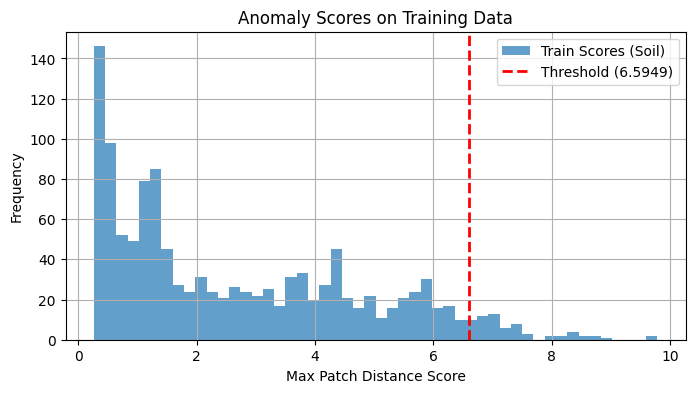

In [13]:
# ███ Cell 2: Build Memory Bank (from Training Soil Images), Fit NN, Determine Threshold ███
print("\n--- Building Memory Bank & Fitting Nearest Neighbors ---")
all_patch_features_list = []
# Load actual training images and extract features
# This part is memory intensive; ideally, load images in batches if too many
loaded_train_images_for_patch = []
for path in train_image_paths:
    img = load_and_preprocess_image_patch(path)
    if img is not None: loaded_train_images_for_patch.append(img)
if not loaded_train_images_for_patch: raise ValueError("No training images loaded for patch extraction.")
X_train_patch_np = np.array(loaded_train_images_for_patch)
del loaded_train_images_for_patch

preprocessed_train_images = preprocess_for_backbone(X_train_patch_np)

print(f"Extracting features from {preprocessed_train_images.shape[0]} training images...")
for i in range(0, len(preprocessed_train_images), BATCH_SIZE_FEATURES):
    batch_imgs = preprocessed_train_images[i:i+BATCH_SIZE_FEATURES]
    batch_feature_maps_list = feature_extractor.predict(batch_imgs, verbose=0) # List of [batch,H,W,C] per layer

    for img_idx_in_batch in range(batch_imgs.shape[0]): # For each image in the current batch
        img_patch_features_from_layers = []
        for layer_idx in range(len(FEATURE_EXTRACTOR_LAYER_NAMES)): # For each feature map from selected layers
            feature_map = batch_feature_maps_list[layer_idx][img_idx_in_batch] # H,W,C
            patches = feature_map.reshape(-1, feature_map.shape[-1]) # (H*W, C_layer)
            img_patch_features_from_layers.append(patches)
        # Concatenate features from different layers for each patch location (depth-wise)
        # This assumes the H*W from different layers are compatible or one is chosen (e.g. smallest H*W)
        # For simplicity here, if H*W differ, this naive concat might be an issue.
        # PatchCore aligns and pools features to a common grid. Here, we simplify.
        # A common strategy is to resize all feature maps to the same H,W before concatenating.
        # For now, let's assume they are similar enough or take the one from the last layer.
        # Taking features from the last specified layer for patch reshaping:
        all_patch_features_list.append(img_patch_features_from_layers[-1]) # Using only patches from the last feature map in FEATURE_EXTRACTOR_LAYER_NAMES

if not all_patch_features_list: raise ValueError("No patch features extracted.")
all_patch_features_np = np.concatenate(all_patch_features_list, axis=0)
print(f"Total extracted patch features shape: {all_patch_features_np.shape}")

# Simplified Coreset: Random Sampling
n_coreset_samples = max(1, int(all_patch_features_np.shape[0] * CORESET_PERCENTAGE))
if all_patch_features_np.shape[0] == 0: raise ValueError("all_patch_features_np is empty")
actual_coreset_samples = min(n_coreset_samples, all_patch_features_np.shape[0]) # Ensure not to exceed available
random_indices = np.random.choice(all_patch_features_np.shape[0], actual_coreset_samples, replace=False)
memory_bank_features = all_patch_features_np[random_indices]
print(f"Memory bank created with shape: {memory_bank_features.shape}")

nn_model = NearestNeighbors(n_neighbors=1, algorithm='auto', metric='minkowski', p=2) # p=2 is Euclidean
nn_model.fit(memory_bank_features)
print("NearestNeighbors model fitted on memory bank.")

# --- Determine Anomaly Score Threshold ---
print("\n--- Determining Anomaly Score Threshold ---")
train_anomaly_scores = []
# Use the same `all_patch_features_np` (features from all training image patches) to find distances to the coreset
# This avoids re-predicting on training images if features are already available
# For each patch feature in the full set, find its distance to the nearest in the coreset
distances_to_coreset, _ = nn_model.kneighbors(all_patch_features_np) # Get distance for each original patch to coreset

# To get per-image anomaly scores, we need to group these patch distances by image
# This was simplified above by appending only the last layer's patches per image.
# The current `all_patch_features_np` is a concatenation of all patches from all images.
# We need to rescore images.
print("Scoring training images to set threshold...")
temp_img_scores = []
original_patches_per_image = all_patch_features_np.shape[0] // X_train_patch_np.shape[0] # Approx if all same size

idx_start = 0
for _ in range(X_train_patch_np.shape[0]): # For each training image
    idx_end = idx_start + original_patches_per_image
    if idx_end > distances_to_coreset.shape[0]: idx_end = distances_to_coreset.shape[0]
    if idx_start >= idx_end : break # Avoid empty slice

    current_image_patch_distances = distances_to_coreset[idx_start:idx_end]
    if len(current_image_patch_distances) > 0:
        temp_img_scores.append(np.max(current_image_patch_distances)) # Image score is max patch distance
    idx_start = idx_end
train_anomaly_scores = np.array(temp_img_scores)

if len(train_anomaly_scores) == 0: raise ValueError("No training anomaly scores computed for thresholding.")
patch_anomaly_threshold = np.percentile(train_anomaly_scores, PATCH_ANOMALY_THRESHOLD_PERCENTILE)
print(f"Patch Anomaly Score Threshold (at {PATCH_ANOMALY_THRESHOLD_PERCENTILE}th percentile): {patch_anomaly_threshold:.6f}")

plt.figure(figsize=(8,4)); plt.hist(train_anomaly_scores, bins=50, alpha=0.7, label='Train Scores (Soil)')
plt.axvline(patch_anomaly_threshold, color='r', ls='--', lw=2, label=f'Threshold ({patch_anomaly_threshold:.4f})')
plt.title('Anomaly Scores on Training Data'); plt.xlabel('Max Patch Distance Score'); plt.ylabel('Frequency')
plt.legend(); plt.grid(True); plt.show()
del X_train_patch_np # Free memory
del preprocessed_train_images
del all_patch_features_np

In [14]:
# ███ Cell 3: Test Data Prediction and Submission ███
print("\n--- Predicting on Test Data & Creating Submission ---")
patch_predictions_list = []

for index, row in test_ids_df.iterrows():
    image_id = row['image_id']
    image_path = os.path.join(TEST_IMAGE_DIR, image_id)
    test_img_arr = load_and_preprocess_image_patch(image_path)

    if test_img_arr is not None:
        preprocessed_test_img = preprocess_for_backbone(np.expand_dims(test_img_arr, axis=0))
        test_feature_maps_list = feature_extractor.predict(preprocessed_test_img, verbose=0)

        # Extract and concatenate patch features from the test image (simplified to last layer's patches)
        # For more robust: test_img_patch_features_from_layers = [] ... then concatenate
        test_img_patches = test_feature_maps_list[-1][0].reshape(-1, test_feature_maps_list[-1][0].shape[-1])

        if test_img_patches.shape[0] > 0:
            distances_test, _ = nn_model.kneighbors(test_img_patches)
            image_anomaly_score_test = np.max(distances_test)
        else: # No patches extracted, e.g. if image was too small for convolutions
            image_anomaly_score_test = patch_anomaly_threshold + 1 # Treat as anomaly

        label = 1 if image_anomaly_score_test <= patch_anomaly_threshold else 0
        patch_predictions_list.append({'image_id': image_id, 'label': label})
    else:
        patch_predictions_list.append({'image_id': image_id, 'label': 0}) # Default for unreadable

    if (index + 1) % 200 == 0: print(f"  Processed {index + 1}/{len(test_ids_df)} test images...")

submission_patch_df = pd.DataFrame(patch_predictions_list)
if os.path.exists(SAMPLE_SUBMISSION_FILE):
    sample_sub_df = pd.read_csv(SAMPLE_SUBMISSION_FILE)
    submission_patch_df = submission_patch_df.reindex(columns=sample_sub_df.columns)
    if 'label' in submission_patch_df.columns: submission_patch_df['label'] = submission_patch_df['label'].fillna(0).astype(int)

output_filename_patch = f'submission_PatchModel_th{PATCH_ANOMALY_THRESHOLD_PERCENTILE}p.csv'
submission_patch_df.to_csv(output_filename_patch, index=False)
print(f"\nSubmission file '{output_filename_patch}' created.")
print(submission_patch_df['label'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Optional: Quick visualization of some results (can be run in a new cell)
# n_viz = 5
# sample_viz = submission_patch_df.sample(n_viz)
# plt.figure(figsize=(15, 5))
# for i, (idx, r) in enumerate(sample_viz.iterrows()):
#     img = load_and_preprocess_image_patch(os.path.join(TEST_IMAGE_DIR, r['image_id']))
#     plt.subplot(1, n_viz, i+1)
#     if img is not None: plt.imshow(img)
#     plt.title(f"ID: ...{r['image_id'][-10:]}\nPred: {'Soil' if r['label']==1 else 'Not Soil'}", fontsize=8)
#     plt.axis('off')
# plt.tight_layout(); plt.show()


--- Predicting on Test Data & Creating Submission ---
  Processed 200/967 test images...
  Processed 400/967 test images...
  Processed 600/967 test images...
  Processed 800/967 test images...

Submission file 'submission_PatchModel_th95p.csv' created.
label
1    97.62%
0     2.38%
Name: proportion, dtype: object
